# Import and download Zipfiles

In [1]:
from data_model.DataCleaner import *
from dl_client import DatalakeClient
from tests_utils.manage_excel_support_file import *
import pandas as pd

client = DatalakeClient()

In [10]:
search = client.query_files(
    query={'custom.level' : 'raw', 'custom.source' : 'ADNI', 'custom.file_code': ['UCD_ADNI1_WMH', 'UCD_WMH', 'UCSDVOL']}) #'ADNIMERGE', 'UCSFFSX51', 'UCSFFSX6', 'UCSFFSX7', 'UCSFFSX', 'UCSFFSX51_ADNI1_3T','UCSFFSL51ALL', 'UCSFFSL51', 'UCSFFSL51Y1', 'UCSFFSL'
print([x['filename'] for x in search['included_files']])

['UCSDVOL_11Aug2025.csv', 'UCD_ADNI1_WMH_11Aug2025.csv', 'UCD_WMH_11Aug2025.csv']


In [ ]:
# verifies which files of interest are in the search ==> fix the search to download only necessary files
files = [x['filename'] for x in search['included_files']]
file_ucd = [x for x in files if 'UCD' in x]
file_ucsdvol = [x for x in files if 'UCSD' in x]
print(file_ucsdvol)

['UCSDVOL_11Aug2025.csv']


In [11]:
# download the founded files through the search
zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True)

# Analysis 1 file

In [24]:
file_name = list(zip_files.keys())[0]
print(file_name)
df = zip_files[file_name]
df_new = df.copy(deep=True)
df_new.head()

UCSDVOL_11Aug2025.csv


,RID,SITEID,VISCODE,USERDATE,EXAMDATE,LONISID,CDATE,QCPASS,BRAIN,EICV,...,RINFLATVEN,LMIDTEMP,RMIDTEMP,LINFTEMP,RINFTEMP,LFUSIFORM,RFUSIFORM,LENTORHIN,RENTORHIN,update_stamp
0,2,107,sc,2010-12-20,2005-08-26,1945.0,12/09/2010,1,1225060,1845620,...,2894.00,2.63800,2.65400,2.60000,2.69700,2.27600,2.40600,3.04200,3.13700,2010-12-20 00:00:00.0
1,3,107,sc,2010-12-20,2005-09-01,1948.0,12/09/2010,1,1131240,1709170,...,5858.00,2.32300,2.40300,2.30300,2.27100,2.00000,2.19200,1.77100,1.94300,2010-12-20 00:00:00.0
2,3,107,m06,2010-12-20,2006-03-13,4081.0,12/09/2010,1,1120490,1709170,...,6302.91,2.26782,2.36287,2.23927,2.22152,1.93687,2.13976,1.72019,1.94679,2010-12-20 00:00:00.0
3,3,107,m12,2010-12-20,2006-09-12,5186.0,12/09/2010,1,1114890,1709170,...,6766.94,2.23919,2.31284,2.20818,2.18546,1.91745,2.11006,1.67185,1.89393,2010-12-20 00:00:00.0
4,3,107,m24,2010-12-20,2007-09-12,11918.0,12/09/2010,1,1101410,1709170,...,7852.09,2.17043,2.23926,2.10359,2.09967,1.83735,2.02294,1.61964,1.77147,2010-12-20 00:00:00.0


In [28]:
print(np.array(df_new.columns))

['RID' 'SITEID' 'VISCODE' 'USERDATE' 'EXAMDATE' 'LONISID' 'CDATE' 'QCPASS'
 'BRAIN' 'EICV' 'VENTRICLES' 'LHIPPOC' 'RHIPPOC' 'LINFLATVEN' 'RINFLATVEN'
 'LMIDTEMP' 'RMIDTEMP' 'LINFTEMP' 'RINFTEMP' 'LFUSIFORM' 'RFUSIFORM'
 'LENTORHIN' 'RENTORHIN' 'update_stamp']


In [33]:
unique_values = df_new['QCPASS'].unique()
if 1 in unique_values or 0 in unique_values:
    print('works')
else:
    print('not works')
print(type(unique_values[0]))

works
<class 'numpy.int64'>


In [27]:
print('total subjects: ', len(df_new['RID'].unique()))
print('subjects with multiple visits: ', (df_new['RID'].value_counts()>1).sum())

total subjects:  811
subjects with multiple visits:  760


In [17]:
volumes = ['BRAIN', 'EICV', 'VENTRICLES', 'LHIPPOC', 'RHIPPOC', 'LMIDTEMP', 'RMIDTEMP', 'LFUSIFORM', 'RFUSIFORM', 'LENTORHIN', 'RENTORHIN']
df_volumes = df_new[volumes]

print(df_volumes.describe())


              BRAIN          EICV     VENTRICLES      LHIPPOC      RHIPPOC  \
count  3.128000e+03  3.128000e+03    3128.000000  3128.000000  3128.000000   
mean   9.798756e+05  1.467064e+06   47763.609827  3136.612327  3303.904290   
std    1.063964e+05  1.469675e+05   24541.309949   580.470644   621.437159   
min    6.290160e+05  1.059560e+06    7552.460000  1287.930000   569.549000   
25%    9.049070e+05  1.360760e+06   29697.625000  2717.465000  2849.007500   
50%    9.759680e+05  1.461500e+06   42492.950000  3141.090000  3328.920000   
75%    1.046885e+06  1.566720e+06   60396.450000  3532.505000  3759.490000   
max    1.361820e+06  1.951440e+06  168830.000000  5514.940000  5750.400000   

          LMIDTEMP     RMIDTEMP    LFUSIFORM    RFUSIFORM    LENTORHIN  \
count  3128.000000  3128.000000  3128.000000  3128.000000  3128.000000   
mean      2.400060     2.445451     2.248983     2.240654     2.855733   
std       0.242266     0.248942     0.223280     0.219798     0.517119   
m

In [18]:
percentiles = [1, 99]

# Creazione di un DataFrame con i percentili per una visualizzazione più chiara
percentile_df = pd.DataFrame(index=volumes, columns=['1° percentile', '99° percentile'])
for volume in volumes:
    percentile_df.loc[volume, '1° percentile'] = df_volumes[volume].quantile(0.01)
    percentile_df.loc[volume, '99° percentile'] = df_volumes[volume].quantile(0.99)

print("=== TABELLA RIASSUNTIVA ===")
percentile_df.round(6)

=== TABELLA RIASSUNTIVA ===


,1° percentile,99° percentile
BRAIN,754149.98,1244134.8
EICV,1160760.7,1810930.0
VENTRICLES,12435.164,120963.48
LHIPPOC,1823.053,4420.7554
RHIPPOC,1981.0673,4613.8562
LMIDTEMP,1.711391,2.85992
RMIDTEMP,1.74831,2.912928
LFUSIFORM,1.659481,2.719437
RFUSIFORM,1.674979,2.712606
LENTORHIN,1.717978,3.787554


# Merging multiple files R & L

In [9]:
df_volumes = pd.DataFrame()
for file in zip_files.keys():
    df = zip_files[file]
    df_new = df.copy(deep=True)
    df_new.head()
    Rvolumes = ['RVentricle', 'RHippocampus', 'REntorhinal', 'RFusiform', 'RMidTemp']
    Lvolumes = ['LVentricle', 'LHippocampus', 'LEntorhinal', 'LFusiform', 'LMidTemp']
    volumes = ['Ventricles', 'Hippocampus', 'Entorhinal', 'Fusiform', 'MidTemp']
    df_R = df_new[Rvolumes]
    df_L = df_new[Lvolumes]
    df_R.columns = volumes
    df_L.columns = volumes
    df_volumes = pd.concat([df_volumes, df_R])
    df_volumes = pd.concat([df_volumes, df_L])
    

In [11]:
df_volumes

,Ventricles,Hippocampus,Entorhinal,Fusiform,MidTemp
0,55425.0,4219.0,1936.0,7252.0,15683.0
1,28743.0,2376.0,985.0,8005.0,10387.0
2,30036.0,2471.0,1183.0,7010.0,9311.0
3,30538.0,2310.0,834.0,7624.0,9736.0
4,33017.0,2269.0,545.0,7264.0,9316.0
...,...,...,...,...,...
478,8646.0,1867.0,1673.0,5974.0,7350.0
479,39083.0,2106.0,1188.0,5458.0,6642.0
480,39771.0,2289.0,1241.0,6027.0,7406.0
481,40053.0,2384.0,938.0,5705.0,7171.0


In [12]:
print(df_volumes.describe())

         Ventricles   Hippocampus    Entorhinal      Fusiform       MidTemp
count  23887.000000  23324.000000  23300.000000  22704.000000  23321.000000
mean   19961.539896   3361.011525   1734.405966   8612.721503   9640.829681
std    11456.444506    639.381953    474.700166   1507.773704   1767.330944
min     2003.000000    734.000000     34.000000   2154.000000   1958.000000
25%    11663.200000   2934.525000   1418.000000   7621.000000   8499.000000
50%    17399.000000   3416.000000   1742.000000   8605.000000   9654.000000
75%    25227.000000   3812.000000   2048.000000   9601.250000  10800.000000
max    87716.000000   5991.000000   4239.000000  16787.000000  17471.000000


In [13]:
percentiles = [1, 99]

# Creazione di un DataFrame con i percentili per una visualizzazione più chiara
percentile_df = pd.DataFrame(index=volumes, columns=['1° percentile', '99° percentile'])
for volume in volumes:
    percentile_df.loc[volume, '1° percentile'] = df_volumes[volume].quantile(0.01)
    percentile_df.loc[volume, '99° percentile'] = df_volumes[volume].quantile(0.99)

print("=== TABELLA RIASSUNTIVA ===")
percentile_df.round(6)

=== TABELLA RIASSUNTIVA ===


,1° percentile,99° percentile
Ventricles,4491.72,57941.106
Hippocampus,1866.23,4715.54
Entorhinal,695.0,2900.02
Fusiform,5114.03,12232.97
MidTemp,5323.8,13798.0


# Merging multiple files full volumes

In [17]:
df_volumes = pd.DataFrame()
for file in zip_files.keys():
    df = zip_files[file]
    df_new = df.copy(deep=True)
    df_new.head()
    volumes = [x for x in ['ICV', 'Ventricles', 'Hippocampus', 'Entorhinal', 'Fusiform', 'MidTemp'] if x in df_new.columns]
    df_volumes = pd.concat([df_volumes, df_new[volumes]])
    

In [18]:
df_volumes

,ICV,Ventricles,Hippocampus,Entorhinal,Fusiform,MidTemp
0,1984660.0,118233.0,8336.0,4177.0,16559.0,27936.0
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
478,1278660.0,NaN,NaN,NaN,NaN,NaN
479,1432980.0,NaN,NaN,NaN,NaN,NaN
480,1429390.0,NaN,NaN,NaN,NaN,NaN
481,1426540.0,NaN,NaN,NaN,NaN,NaN


In [19]:
print(df_volumes.describe())

                ICV     Ventricles   Hippocampus   Entorhinal      Fusiform  \
count  2.135000e+04    8727.000000   8137.000000  7746.000000   7746.000000   
mean   1.518019e+06   42188.100000   6750.473209  3553.466047  17303.657113   
std    1.729892e+05   23149.299469   1230.321684   856.775081   2795.803120   
min    7.161330e+05    5650.000000   2219.000000   976.000000   7739.000000   
25%    1.398038e+06   25164.500000   5922.000000  2985.250000  15482.250000   
50%    1.506112e+06   37305.600000   6848.100000  3597.000000  17301.000000   
75%    1.622260e+06   53500.000000   7628.000000  4133.000000  19158.750000   
max    3.500154e+06  162729.000000  11207.000000  7062.000000  29950.000000   

            MidTemp  
count   7746.000000  
mean   19401.276530  
std     3131.342499  
min     8044.000000  
25%    17379.250000  
50%    19403.500000  
75%    21539.500000  
max    32324.000000  


In [21]:
percentiles = [1, 99]
volumes = ['ICV', 'Ventricles', 'Hippocampus', 'Entorhinal', 'Fusiform', 'MidTemp']
# Creazione di un DataFrame con i percentili per una visualizzazione più chiara
percentile_df = pd.DataFrame(index=volumes, columns=['1° percentile', '99° percentile'])
for volume in volumes:
    percentile_df.loc[volume, '1° percentile'] = df_volumes[volume].quantile(0.01)
    percentile_df.loc[volume, '99° percentile'] = df_volumes[volume].quantile(0.99)

print("=== TABELLA RIASSUNTIVA ===")
percentile_df.round(6)

=== TABELLA RIASSUNTIVA ===


,1° percentile,99° percentile
ICV,1178000.0,1950280.0
Ventricles,9942.24,116400.08
Hippocampus,3898.88,9385.0
Entorhinal,1595.45,5572.55
Fusiform,10739.3,23874.05
MidTemp,11546.9,26670.55


# RAW file analysis

In [6]:
print([x['filename'] for x in search['included_files']])

['UCSFFSL51ALL_08_01_16_11Aug2025.csv', 'UCSFFSL51Y1_08_01_16_11Aug2025.csv', 'UCSFFSL51_03_01_22_11Aug2025.csv', 'UCSFFSL_02_01_16_11Aug2025.csv']


In [46]:
file_name = 'UCSFFSL_02_01_16_11Aug2025.csv'
df = zip_files[file_name]
df_new = df.copy(deep=True)
df_new.head()

,RID,VISCODE,VISCODE2,EXAMDATE,VERSION,FLDSTRENG,LONISID,LONIUID,IMAGEUID,RUNDATE,...,ST98CV,ST98SA,ST98TA,ST98TS,ST99CV,ST99SA,ST99TA,ST99TS,ST9SV,update_stamp
0,3,m06,m06,2006-03-13,2009-07-01,1.5,4081,15240,31863,2009-07-01,...,4253,2131,2.034,0.720,10022,3475,2.525,0.693,2808,2016-02-02 09:33:37.0
1,3,m12,m12,2006-09-12,2009-07-01,1.5,5186,19096,35576,2009-07-01,...,4158,2171,1.991,0.678,9758,3493,2.448,0.670,2939,2016-02-02 09:33:37.0
2,3,m24,m24,2007-09-12,2009-07-02,1.5,11918,39296,88252,2009-07-02,...,3901,2091,1.893,0.648,9237,3243,2.431,0.671,2987,2016-02-02 09:33:37.0
3,3,sc,sc,2005-09-01,2009-07-01,1.5,1948,9127,32237,2009-07-01,...,4046,1947,2.021,0.745,10097,3292,2.579,0.659,2863,2016-02-02 09:33:37.0
4,4,m06,m06,2006-05-25,2009-08-24,1.5,4007,14969,64636,2009-08-24,...,3838,1638,2.138,0.656,10872,3526,2.645,0.639,1396,2016-02-02 09:33:37.0


In [53]:
keys_list = list(df_new.keys())
if 'COLPROT' in keys_list:
    print('COLPROT in keys_list')
else:
    print('COLPROT not in keys_list')
other_list = [key for key in keys_list if key[:2] != 'ST' and not key[2].isdigit()]
print(other_list)

COLPROT not in keys_list
['RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'VERSION', 'FLDSTRENG', 'LONISID', 'LONIUID', 'IMAGEUID', 'RUNDATE', 'BASETP1', 'BASETP2', 'BASETP3', 'BASETP4', 'BASETP5', 'BASETP6', 'BASETP7', 'BASETP8', 'OVERALLQC', 'TEMPQC', 'FRONTQC', 'PARQC', 'INSULAQC', 'OCCQC', 'BGQC', 'CWMQC', 'VENTQC', 'update_stamp']


In [48]:
volumes = [key for key in keys_list if  key[:2] == 'ST' and key[2].isdigit()]
print('lista volumi:\n', volumes)

lista volumi:
 ['ST100SV', 'ST101SV', 'ST102CV', 'ST102SA', 'ST102TA', 'ST102TS', 'ST103CV', 'ST103SA', 'ST103TA', 'ST103TS', 'ST104CV', 'ST104SA', 'ST104TA', 'ST104TS', 'ST105CV', 'ST105SA', 'ST105TA', 'ST105TS', 'ST106CV', 'ST106SA', 'ST106TA', 'ST106TS', 'ST107CV', 'ST107SA', 'ST107TA', 'ST107TS', 'ST108CV', 'ST108SA', 'ST108TA', 'ST108TS', 'ST109CV', 'ST109SA', 'ST109TA', 'ST109TS', 'ST10CV', 'ST110CV', 'ST110SA', 'ST110TA', 'ST110TS', 'ST111CV', 'ST111SA', 'ST111TA', 'ST111TS', 'ST112SV', 'ST113CV', 'ST113SA', 'ST113TA', 'ST113TS', 'ST114CV', 'ST114SA', 'ST114TA', 'ST114TS', 'ST115CV', 'ST115SA', 'ST115TA', 'ST115TS', 'ST116CV', 'ST116SA', 'ST116TA', 'ST116TS', 'ST117CV', 'ST117SA', 'ST117TA', 'ST117TS', 'ST118CV', 'ST118SA', 'ST118TA', 'ST118TS', 'ST119CV', 'ST119SA', 'ST119TA', 'ST119TS', 'ST11SV', 'ST120SV', 'ST121CV', 'ST121SA', 'ST121TA', 'ST121TS', 'ST122SV', 'ST123CV', 'ST123SA', 'ST123TA', 'ST123TS', 'ST124SV', 'ST125SV', 'ST126SV', 'ST127SV', 'ST128SV', 'ST129CV', 'ST129S

In [49]:
df_new['STATUS'].value_counts()

STATUS
complete    3537
partial       33
Name: count, dtype: int64

In [52]:
tot_sub = len(df_new['RID'].unique())
print('totale subject:', tot_sub)
multiple_visists = (df_new['RID'].value_counts() > 2).sum()
print('subjects with multiple visits: ', multiple_visists)

totale subject: 761
subjects with multiple visits:  699


In [45]:
code_list = ['ST37SV','ST10CV','ST24CV','ST26CV','ST29SV','ST40CV','ST96SV','ST83CV','ST85CV','ST88SV','ST99CV']
label_list = ['Left Lateral Ventricle','Estimated Intracranial Volume (ICV)','Left Entorhinal','Left Fusiform','Left Hippocampus','Left Middle Temporal','Right Lateral Ventricle','Right Entorhinal','Right Fusiform','Right Hippocampus','Right Middle Temporal']

for x, code in enumerate(code_list):
    if code in volumes:
        print(label_list[x]+' yes --> '+code)
    else:
        print(label_list[x]+' missing')

Left Lateral Ventricle yes --> ST37SV
Estimated Intracranial Volume (ICV) yes --> ST10CV
Left Entorhinal yes --> ST24CV
Left Fusiform yes --> ST26CV
Left Hippocampus yes --> ST29SV
Left Middle Temporal yes --> ST40CV
Right Lateral Ventricle yes --> ST96SV
Right Entorhinal yes --> ST83CV
Right Fusiform yes --> ST85CV
Right Hippocampus yes --> ST88SV
Right Middle Temporal yes --> ST99CV


In [34]:
# Selezioniamo solo le colonne dei volumi ICV
code_list = ['RID', 'VISCODE2','ST10CV', 'ST37SV','ST96SV','ST24CV','ST83CV','ST26CV','ST85CV','ST29SV','ST88SV','ST40CV','ST99CV']


# Creiamo il DataFrame indipendente
df_volumes = df_new[code_list].copy()

In [35]:
# Definiamo i nuovi nomi per le colonne
nuovi_nomi = {
    'ST10CV': 'ICV',
    'ST37SV': 'LVentricle',
    'ST96SV': 'RVentricle',
    'ST24CV': 'LEntorhinal',
    'ST83CV': 'REntorhinal',
    'ST26CV': 'LFusiform',
    'ST85CV': 'RFusiform',
    'ST29SV': 'LHippocampus',
    'ST88SV': 'RHippocampus',
    'ST40CV': 'LMIdTemp',
    'ST99CV': 'RMidTemp'}

# Rinominiamo le colonne
df_volumes = df_volumes.rename(columns=nuovi_nomi)
df_volumes.head()

,RID,VISCODE2,ICV,LVentricle,RVentricle,LEntorhinal,REntorhinal,LFusiform,RFusiform,LHippocampus,RHippocampus,LMIdTemp,RMidTemp
0,21,m60,1407080,8101,10163,1748,1588,9049,9106,3968,3909,8644,9302
1,21,m72,1407080,9588,12052,1640,1530,8728,9271,3735,3870,8472,8871
2,89,m48,1500900,9517,12115,2094,1907,10609,12041,3902,3503,11126,12529
3,89,m72,1500900,9698,12375,2163,1975,10662,12188,3887,3540,11447,12606
4,295,m72,1678700,27445,19935,2019,1918,9552,8701,3173,3166,9253,10020


In [16]:
df_volumes['Ventricles'] = df_volumes['LVentricle'] + df_volumes['RVentricle']
df_volumes['Entorhinal'] = df_volumes["LEntorhinal"]+ df_volumes["REntorhinal"]
df_volumes['Fusiform'] = df_volumes["LFusiform"]+ df_volumes["RFusiform"]
df_volumes['Hippocampus'] = df_volumes["LHippocampus"]+ df_volumes["RHippocampus"]
df_volumes['MidTemp'] = df_volumes["LMIdTemp"]+ df_volumes["RMidTemp"]
df_volumes.head()
#df_volumes[["LFusiform", "RFusiform"]].mean(axis=1)

,RID,VISCODE2,ICV,LVentricle,RVentricle,LEntorhinal,REntorhinal,LFusiform,RFusiform,LHippocampus,RHippocampus,LMIdTemp,RMidTemp,Ventricles,Entorhinal,Fusiform,Hippocampus,MidTemp
0,21,m60,1397040,8070,10212,2124,1447,9102,9261,3965,3870,8100,9027,18282,3571,18363,7835,17127
1,21,m72,1397040,9665,11972,2036,1503,8829,9355,3714,3790,7979,8646,21637,3539,18184,7504,16625
2,21,m84,1397040,8914,11253,2116,1411,9054,9030,3932,3834,8246,8935,20167,3527,18084,7766,17181
3,21,m96,1397040,8996,11187,1915,1529,8838,9122,3821,3773,8089,8789,20183,3444,17960,7594,16878
4,21,m120,1397040,9992,12192,1946,1367,8514,8983,3708,3690,7369,8611,22184,3313,17497,7398,15980


In [17]:
volumes = ['Ventricles', 'Hippocampus', 'Entorhinal', 'Fusiform', 'MidTemp']
for volume in volumes:
    df_volumes[volume+'%ICV'] = (df_volumes[volume]/df_volumes['ICV'])*100
df_volumes.head()

,RID,VISCODE2,ICV,LVentricle,RVentricle,LEntorhinal,REntorhinal,LFusiform,RFusiform,LHippocampus,...,Ventricles,Entorhinal,Fusiform,Hippocampus,MidTemp,Ventricles%ICV,Hippocampus%ICV,Entorhinal%ICV,Fusiform%ICV,MidTemp%ICV
0,21,m60,1397040,8070,10212,2124,1447,9102,9261,3965,...,18282,3571,18363,7835,17127,1.308624,0.560829,0.255612,1.314422,1.225949
1,21,m72,1397040,9665,11972,2036,1503,8829,9355,3714,...,21637,3539,18184,7504,16625,1.548775,0.537136,0.253321,1.301609,1.190016
2,21,m84,1397040,8914,11253,2116,1411,9054,9030,3932,...,20167,3527,18084,7766,17181,1.443552,0.555890,0.252462,1.294451,1.229814
3,21,m96,1397040,8996,11187,1915,1529,8838,9122,3821,...,20183,3444,17960,7594,16878,1.444697,0.543578,0.246521,1.285575,1.208126
4,21,m120,1397040,9992,12192,1946,1367,8514,8983,3708,...,22184,3313,17497,7398,15980,1.587929,0.529548,0.237144,1.252434,1.143847


In [18]:
volumesICV = ['Ventricles%ICV', 'Hippocampus%ICV', 'Entorhinal%ICV', 'Fusiform%ICV', 'MidTemp%ICV']

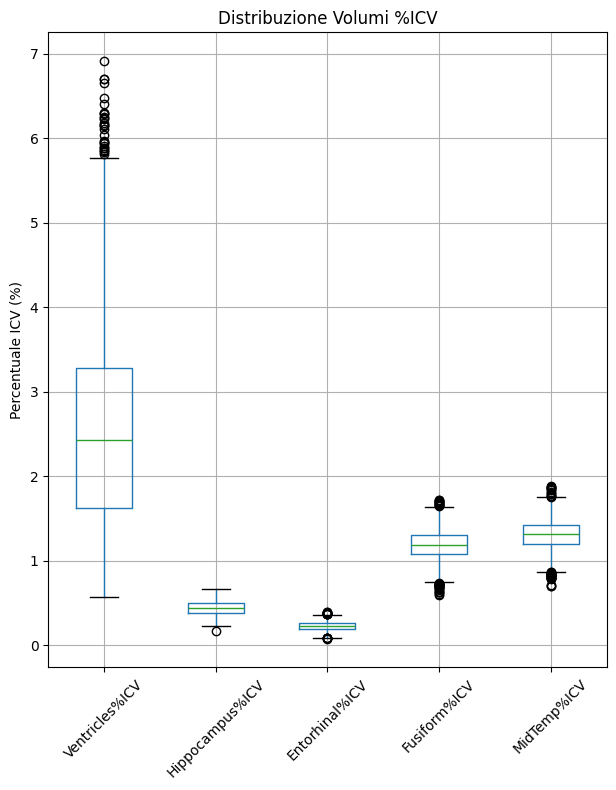

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione del plot
plt.figure(figsize=(12, 8))

# Box plot per le percentuali ICV
volumesICV = ['Ventricles%ICV', 'Hippocampus%ICV', 'Entorhinal%ICV', 'Fusiform%ICV', 'MidTemp%ICV']
df_volumesICV = df_volumes[volumesICV]

plt.subplot(1, 2, 2)
df_volumesICV.boxplot(rot=45)
plt.title('Distribuzione Volumi %ICV')
plt.ylabel('Percentuale ICV (%)')

plt.tight_layout()
plt.show()


In [20]:
# Statistiche descrittive per i volumi

print("\n=== STATISTICHE DESCRITTIVE VOLUMI %ICV ===")
print(df_volumesICV.describe())




=== STATISTICHE DESCRITTIVE VOLUMI %ICV ===
       Ventricles%ICV  Hippocampus%ICV  Entorhinal%ICV  Fusiform%ICV  \
count     2009.000000      2009.000000     2009.000000   2009.000000   
mean         2.572143         0.442982        0.227849      1.185918   
std          1.212131         0.087276        0.050704      0.175575   
min          0.577737         0.172816        0.080585      0.601851   
25%          1.628142         0.378998        0.193604      1.076641   
50%          2.435782         0.443260        0.231234      1.185081   
75%          3.288998         0.503098        0.262344      1.301040   
max          6.914024         0.673497        0.394289      1.716103   

       MidTemp%ICV  
count  2009.000000  
mean      1.310723  
std       0.178251  
min       0.698320  
25%       1.202340  
50%       1.313164  
75%       1.423907  
max       1.889867  


In [ ]:
# Calcolo del 1° e 99° percentile per ciascun volume ICV
print("=== 1° E 99° PERCENTILE PER VOLUMI %ICV ===")
print()

percentiles = [1, 99]

# Creazione di un DataFrame con i percentili per una visualizzazione più chiara
percentile_df = pd.DataFrame(index=volumesICV, columns=['1° percentile', '99° percentile'])
for volume in volumesICV:
    percentile_df.loc[volume, '1° percentile'] = df_volumesICV[volume].quantile(0.01)
    percentile_df.loc[volume, '99° percentile'] = df_volumesICV[volume].quantile(0.99)

print("=== TABELLA RIASSUNTIVA ===")
percentile_df.round(6)


=== 1° E 99° PERCENTILE PER VOLUMI %ICV ===

=== TABELLA RIASSUNTIVA ===


,1° percentile,99° percentile
Ventricles%ICV,0.766694,6.530903
Hippocampus%ICV,0.291506,0.642994
Entorhinal%ICV,0.116204,0.40236
Fusiform%ICV,0.846472,1.579309
MidTemp%ICV,0.929461,1.804767


In [ ]:
for volume in volumesICV:
    range_10 = abs(percentile_df.loc[volume, '1° percentile'] - percentile_df.loc[volume, '99° percentile'])/10
    percentile_df.loc[volume, '10% range'] = range_10
    percentile_df.loc[volume, 'max%10'] = percentile_df.loc[volume, '99° percentile'] + range_10
    percentile_df.loc[volume, 'max'] = df_volumesICV[volume].max()
    percentile_df.loc[volume, 'min%10'] = percentile_df.loc[volume, '1° percentile'] - range_10
    percentile_df.loc[volume, 'min'] = df_volumesICV[volume].min()

print("=== TABELLA RIASSUNTIVA ===")
percentile_df.round(6)

=== TABELLA RIASSUNTIVA ===


,1° percentile,99° percentile,10% range,max%10,max,min%10,min
Ventricles%ICV,0.766694,6.530903,0.576421,7.107324,8.550066,0.190274,0.588359
Hippocampus%ICV,0.291506,0.642994,0.035149,0.678143,0.714628,0.256357,0.176016
Entorhinal%ICV,0.116204,0.40236,0.028616,0.430976,0.536241,0.087588,0.085514
Fusiform%ICV,0.846472,1.579309,0.073284,1.652593,1.721055,0.773188,0.525870
MidTemp%ICV,0.929461,1.804767,0.087531,1.892297,1.931520,0.841931,0.607021


In [ ]:
# Box plot temporali per ciascun volume ICV - FIGURE SEPARATE
import matplotlib.pyplot as plt
import seaborn as sns

# Filtriamo i dati per includere solo le visite principali (0, 6, 12, 18, 24 mesi)
# Assumendo che le visite siano codificate come 'bl', 'm06', 'm12', 'm18', 'm24', ecc.
visite_principali = df_new['VISCODE'].unique().tolist()
df_temporale = df_new[df_new['VISCODE'].isin(visite_principali)].copy()


volumesICV = ['Ventricles%ICV', 'Hippocampus%ICV', 'Entorhinal%ICV', 'Fusiform%ICV', 'MidTemp%ICV']

# Creiamo una figura separata per ciascun volume ICV
for volume in volumesICV:
    plt.figure(figsize=(12, 8))
    
    # Box plot per il volume specifico usando matplotlib
    df_temporale.boxplot(column=volume, by='VISCODE', ax=plt.gca())
    plt.title(f'Distribuzione {volume} nel tempo', fontsize=14, fontweight='bold')
    plt.xlabel('Visita', fontsize=12)
    plt.ylabel('Percentuale ICV (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Statistics based on DX

In [ ]:
DX_list = [0, 1, 2]
df_DX = df_new[df_new['DX'].isin(DX_list)].copy()
volumesICV = ['Ventricles%ICV', 'Hippocampus%ICV', 'Entorhinal%ICV', 'Fusiform%ICV', 'MidTemp%ICV']

# Creiamo una figura separata per ciascun volume ICV
for volume in volumesICV:
    plt.figure(figsize=(12, 8))
    
    # Box plot per il volume specifico usando matplotlib
    df_DX.boxplot(column=volume, by='DX', ax=plt.gca())
    plt.title(f'Distribuzione {volume} per diagnosi', fontsize=14, fontweight='bold')
    plt.xlabel('Diagnosi', fontsize=12)
    plt.ylabel('Percentuale ICV (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [ ]:
# Analisi statistica delle tendenze per ciascun volume in base alla diagnosi
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("=== ANALISI STATISTICA DELLE TENDENZE PER DIAGNOSI ===")
print()

volumesICV = ['Ventricles%ICV', 'Hippocampus%ICV', 'Entorhinal%ICV', 'Fusiform%ICV', 'MidTemp%ICV']

# Filtriamo i dati per includere solo le visite principali e rimuovere valori NaN nelle diagnosi
df_analisi = df_new[df_new['VISCODE'].isin(visite_principali)].copy()
df_analisi = df_analisi.dropna(subset=['DX'])

print(f"Numero di osservazioni per diagnosi:")
print(df_analisi['DX'].value_counts())
print()

# Analisi per ciascun volume
for volume in volumesICV:
    print(f"\n{'='*60}")
    print(f"ANALISI PER {volume}")
    print(f"{'='*60}")
    
    # Statistiche descrittive per diagnosi
    print(f"\n--- STATISTICHE DESCRITTIVE PER DIAGNOSI ---")
    stats_per_dx = df_analisi.groupby('DX')[volume].agg(['count', 'mean', 'std', 'min', 'max', 'median']).round(4)
    print(stats_per_dx)



In [ ]:
# Rinominazione delle colonne del DataFrame df_volumes
print("=== RINOMINAZIONE DELLE COLONNE ===")
print()

# Definiamo i nuovi nomi per le colonne
nuovi_nomi = {
    'Ventricles%ICV': 'Ventricoli_ICV',
    'Hippocampus%ICV': 'Ippocampo_ICV', 
    'Entorhinal%ICV': 'Entorinale_ICV',
    'Fusiform%ICV': 'Fusiforme_ICV',
    'MidTemp%ICV': 'Temporale_Medio_ICV'
}

# Rinominiamo le colonne
df_volumes = df_volumes.rename(columns=nuovi_nomi)

print("Colonne dopo la rinominazione:")
print(df_volumes.columns.tolist())
print(f"\nShape del DataFrame: {df_volumes.shape}")
print(f"\nPrimi 5 valori con i nuovi nomi:")
print(df_volumes.head())


In [ ]:
# Statistiche del nuovo DataFrame df_volumes
print("=== STATISTICHE DEL DATAFRAME df_volumes ===")
print()

print("Statistiche descrittive:")
print(df_volumes.describe())
print()

print("Informazioni sul DataFrame:")
print(df_volumes.info())
print()

print("Valori mancanti per colonna:")
print(df_volumes.isnull().sum())
print()

print("Memoria utilizzata dal DataFrame:")
print(f"{df_volumes.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


In [ ]:
stats_per_dx = df_analisi.groupby('DX')['MidTemp%ICV'].agg(['count', 'mean', 'std', 'min', 'max', 'median']).round(4)
stats_per_dx

# Small changes to files

In [55]:
from data_model.DataCleaner import *
from dl_client import DatalakeClient
from tests_utils.manage_excel_support_file import *
import pandas as pd

client = DatalakeClient()

In [59]:
search = client.query_files(
    query={'custom.level' : 'cleaned_02', 'custom.source' : 'ADNI', 'custom.file_code': ['UCSFFSX51', 'UCSFFSX6', 'UCSFFSX7', 'UCSFFSX', 'UCSFFSX51_ADNI1_3T']}) #'ADNIMERGE', 'UCSFFSX51', 'UCSFFSX6', 'UCSFFSX7', 'UCSFFSX', 'UCSFFSX51_ADNI1_3T','UCSFFSL51ALL', 'UCSFFSL51', 'UCSFFSL51Y1', 'UCSFFSL'
print([x['filename'] for x in search['included_files']])

['UCSFFSX_11_02_15_11Aug2025_02.csv', 'UCSFFSX7_11Aug2025_02.csv', 'UCSFFSX6_11Aug2025_02.csv', 'UCSFFSX51_11_08_19_11Aug2025_02.csv', 'UCSFFSX51_ADNI1_3T_02_01_16_11Aug2025_02.csv']


In [60]:

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True)

In [61]:
for file in zip_files.keys():
    df = zip_files[file]
    df_new = df.copy(deep=True)
    if 'PHASE' in df_new.columns:
        df_new = df_new.rename(columns={'PHASE': 'COHORT'})
        result = client.upload_dataframe(
            df=df_new,
            object_name=file,
            prefix='cleaned/single_file/',
        )
        print('Sistemato nome variabile della COHORTE per file: '+file)

Sistemato nome variabile della COHORTE per file: UCSFFSX7_11Aug2025_02.csv
Sistemato nome variabile della COHORTE per file: UCSFFSX6_11Aug2025_02.csv
